### Goal: Making heatmaps showing the % of trajectories that land within a grid cell across the entire model time range. We want this as static images and GIF animations

In [1]:
import matplotlib.pyplot as plt
import os
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap

In [2]:
# Let's open a recent model output file

output_dir = "../DailyModelRuns/model_output/netcdf_model_v2"

# List all netCDF files in the output directory
output_files = os.listdir(output_dir)
output_files = [f for f in output_files if f.endswith('.nc')]

# Look at a single file
ds = xr.open_dataset(os.path.join(output_dir, output_files[-1]))
start_date = ds.isel(time=0).time.values.astype(str).split('.')[0]  # Extract date part
end_date = ds.isel(time=-1).time.values.astype(str).split('.')[0]
start_date, end_date

('2025-09-30T15:40:00', '2025-10-02T15:40:00')

### Make a static heat map using xarray plotting function

In [13]:
def compute_heatmap(ds):
    # Shapes: (trajectory, time)
    lon = ds['lon'].values.copy()
    lat = ds['lat'].values.copy()
    status = ds['status'].values.copy()

    n_particles, n_times = lon.shape

    # Define grid edges (lon/lat)
    lon_edges = np.linspace(-123.05, -122.35, 100)
    lat_edges = np.linspace(37.5, 38.1, 100)

    # Prepare 3D array to hold counts: (time, lat_bins, lon_bins)
    counts = np.zeros((n_times, len(lat_edges)-1, len(lon_edges)-1))

    # Compute first stranded index for each particle
    first_strand_idx = np.argmax(status==1, axis=1)  # per particle
    never_stranded = np.all(status==0, axis=1)
    first_strand_idx[never_stranded] = -1  # mark particles that never stranded

    for t_idx in range(n_times):
        # Extract positions at this time
        lon_t = lon[:, t_idx].copy()
        lat_t = lat[:, t_idx].copy()
        
        # Carry-forward stranded positions
        stranded_mask = (first_strand_idx >= 0) & (first_strand_idx <= t_idx)
        traj_idx = np.where(stranded_mask)[0]
        lon_t[traj_idx] = lon[traj_idx, first_strand_idx[traj_idx]]
        lat_t[traj_idx] = lat[traj_idx, first_strand_idx[traj_idx]]

        # Count number of stranded particles in this frame
        num_stranded_frame = np.sum((first_strand_idx >= 0) & (first_strand_idx <= t_idx))
        
        # Remove NaNs
        valid_mask = np.isfinite(lon_t) & np.isfinite(lat_t)
        lon_t = lon_t[valid_mask]
        lat_t = lat_t[valid_mask]
        
        # 2D histogram
        H, _, _ = np.histogram2d(lat_t, lon_t, bins=[lat_edges, lon_edges])
        counts[t_idx, :, :] = H

    # Wrap as xarray DataArray
    heat_da = xr.DataArray(
        counts,
        dims=('time', 'lat_bin', 'lon_bin'),
        coords={
            'time': ds['time'],
            'lat_bin': (lat_edges[:-1] + lat_edges[1:]) / 2,
            'lon_bin': (lon_edges[:-1] + lon_edges[1:]) / 2
        }
    )

    # Mask zeros
    heat_da_masked = heat_da.where(heat_da != 0)

    return heat_da_masked, counts, lat_edges, lon_edges, first_strand_idx


In [14]:
heat_da_masked, counts, lat_edges, lon_edges, first_strand_idx = compute_heatmap(ds)

In [15]:

def plot_heatmap_firsttime(heat_da_masked, counts, lat_edges, lon_edges):
    '''
    Plot heatmap for the first time step in the dataset.
    '''

    # Wrap as xarray DataArray
    heat_da = xr.DataArray(
        counts,
        dims=('time', 'lat_bin', 'lon_bin'),
        coords={'time': ds['time'], 
                'lat_bin': (lat_edges[:-1] + lat_edges[1:])/2,
                'lon_bin': (lon_edges[:-1] + lon_edges[1:])/2}
    )

    # Mask zeros so they don't appear in the color ramp
    heat_da_masked = heat_da.where(heat_da != 0)

    # Create figure and axis with Cartopy projection
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Plot the heatmap
    heat_da_masked.isel(time=0).plot(
        ax=ax,
        x='lon_bin',
        y='lat_bin',
        cmap='magma_r',
        add_colorbar=True
    )

    # Add coastline
    coastline = cfeature.NaturalEarthFeature(
        'physical', 'coastline', '10m',
        edgecolor='black', facecolor='slategrey', linewidth=0.8
    )
    ax.add_feature(coastline, zorder=1)

    # Import bathymetry layer for contours 
    ds_o = xr.open_dataset('/home/pdaniel/SurfaceCurrentMaps/DailyModelRuns/data/sf_bay_topo.nc')
    elv = ds_o['band_data'].values
    xx = ds_o.x.values
    yy = ds_o.y.values

    # Add bathymetry contours for context
    levels = [0,10,20,50,100,200,500,1000]
    ax.contourf(xx,yy,-1*elv[0],zorder=-1,cmap=cmocean.cm.ice_r,levels=levels)
    cont = ax.contour(xx,yy,-1*elv[0],levels=levels[1:],colors='k',linewidths=0.2,linestyles='solid')

    # Set extent if desired
    ax.set_xlim(-123.05, -122.35)
    ax.set_ylim(37.5, 38.1)

    plt.show()


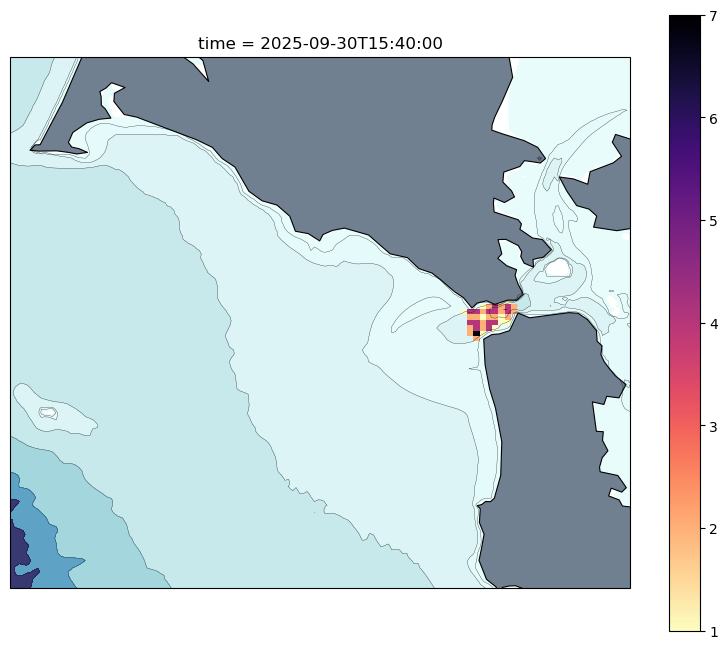

In [16]:
plot_heatmap_firsttime(heat_da_masked, counts, lat_edges, lon_edges)

In [17]:
def plot_heatmap_aggregated(ds, lon_edges, lat_edges):
    """
    Aggregate particle counts over the entire time domain of the model run, and plot % of trajectories per grid cell.

    Parameters:
    - ds: xarray.Dataset with dimensions ('trajectory', 'time') and variables 'lon' and 'lat'
    - lon_edges, lat_edges: 1D arrays defining the grid edges
    """
    # Mask invalid values
    lon = ds['lon'].where(np.isfinite(ds['lon']))
    lat = ds['lat'].where(np.isfinite(ds['lat']))

    n_time = ds.sizes['time']
    n_particles = ds.sizes['trajectory']

    # Prepare array to hold counts per cell
    counts = np.zeros((len(lat_edges)-1, len(lon_edges)-1))

    # Loop over time to accumulate counts
    for t_idx in range(n_time):
        lon_t = lon.isel(time=t_idx).values
        lat_t = lat.isel(time=t_idx).values
        mask = np.isfinite(lon_t) & np.isfinite(lat_t)
        lon_t, lat_t = lon_t[mask], lat_t[mask]

        # 2D histogram
        H, _, _ = np.histogram2d(lat_t, lon_t, bins=[lat_edges, lon_edges])
        counts += H  # sum over time

    # Convert to % of trajectories (normalize by total particle-time points)
    total_points = n_particles * n_time
    pct = (counts / total_points) * 100

    # Wrap as DataArray
    heat_da = xr.DataArray(
        pct,
        dims=('lat_bin', 'lon_bin'),
        coords={
            'lat_bin': (lat_edges[:-1] + lat_edges[1:])/2,
            'lon_bin': (lon_edges[:-1] + lon_edges[1:])/2
        }
    )

    # Mask zeros
    heat_da_masked = heat_da.where(heat_da != 0)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    mesh = heat_da_masked.plot(ax=ax, x='lon_bin', y='lat_bin', cmap='magma_r', add_colorbar=False)
    cbar = fig.colorbar(mesh, ax=ax, label='% of Trajectories in Grid Cell', shrink=0.7) 

    # Add coastline
    coastline = cfeature.NaturalEarthFeature(
        'physical', 'coastline', '10m',
        edgecolor='black', facecolor='slategrey', linewidth=0.8
    )
    ax.add_feature(coastline, zorder=1)

    # Add bathymetry contours
    ds_o = xr.open_dataset('/home/pdaniel/SurfaceCurrentMaps/DailyModelRuns/data/sf_bay_topo.nc')
    elv = ds_o['band_data'].values
    xx = ds_o.x.values
    yy = ds_o.y.values
    levels = [0,5,10,20,50,100,200,500,1000]
    cmap = cmocean.cm.ice_r
    cmap_trunc = ListedColormap(cmap(np.linspace(0.1,1,256)))
    ax.contourf(xx, yy, -1*elv[0], zorder=-1, cmap=cmap_trunc, levels=levels)
    ax.contour(xx, yy, -1*elv[0], levels=levels[1:], colors='k', linewidths=0.5, linestyles='solid')

    # Set extent
    ax.set_xlim(-123.05, -122.35)
    ax.set_ylim(37.5, 38.1)

    # add title with start date
    start_date = ds.isel(time=0).time.values.astype(str).split('.')[0]
    ax.set_title(f'48H Aggregated Heatmap of Particle Trajectories\n(Start Date: {start_date})', fontsize=14)

    plt.savefig('/home/pdaniel/SurfaceCurrentMaps/DailyModelRuns/model_output/heatmaps/heatmap_{}.png'.format(start_date.replace(' ','_').replace(':','-')) , bbox_inches='tight')

    plt.show()
    return heat_da_masked

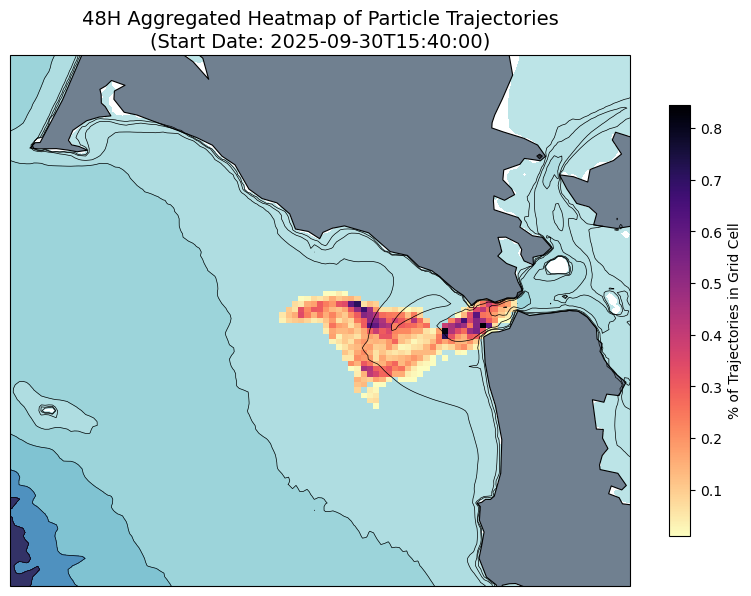

<xarray.DataArray (lat_bin: 99, lon_bin: 99)> Size: 78kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat_bin  (lat_bin) float64 792B 37.5 37.51 37.52 37.52 ... 38.08 38.09 38.1
  * lon_bin  (lon_bin) float64 792B -123.0 -123.0 -123.0 ... -122.4 -122.4

In [18]:
plot_heatmap_aggregated(ds, lon_edges, lat_edges)

In [19]:

def animate_heatmap(heat_da_masked, ds, first_strand_idx):
    """
    Create an animation of the heatmap over time.

    Parameters:
    - heat_da_masked: xarray.DataArray with dimensions ('time', 'lat_bin', 'lon_bin')
    - ds: xarray.Dataset with dimensions ('trajectory', 'time') and variables 'lon', 'lat', 'status'
    - first_strand_idx: 1D array indicating the first time index each particle stranded
    """
    # Create figure and axis with Cartopy projection

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Add bathymetry contours
    ds_o = xr.open_dataset('/home/pdaniel/SurfaceCurrentMaps/DailyModelRuns/data/sf_bay_topo.nc')
    elv = ds_o['band_data'].values
    xx = ds_o.x.values
    yy = ds_o.y.values
    levels = [0,5,10,20,50,100,200,500,1000]
    cmap = cmocean.cm.ice_r
    cmap_trunc = ListedColormap(cmap(np.linspace(0.1,1,256)))
    ax.contourf(xx, yy, -1*elv[0], zorder=-1, cmap=cmap_trunc, levels=levels)
    ax.contour(xx, yy, -1*elv[0], levels=levels[1:], colors='k', linewidths=0.5, linestyles='solid')

    # Add coastline
    coastline = cfeature.NaturalEarthFeature(
        'physical', 'coastline', '10m',
        edgecolor='black', facecolor='slategrey', linewidth=0.8
    )
    ax.add_feature(coastline, zorder=1)

    # Set extent
    ax.set_xlim(-123.05, -122.35)
    ax.set_ylim(37.5, 38.1)

    # Create initial QuadMesh
    mesh = ax.pcolormesh(
        heat_da_masked.lon_bin,
        heat_da_masked.lat_bin,
        heat_da_masked.isel(time=0),
        cmap='magma_r',
        zorder=2
    )
    cbar = fig.colorbar(mesh, ax=ax, label='% of Trajectories in Grid Cell',shrink=0.7)
    n_particles = ds.sizes['trajectory']
    # Update function
    def update(frame):
        mesh.set_array(heat_da_masked.isel(time=frame).values.ravel())
        time_str = pd.to_datetime(heat_da_masked.time.values[frame]).strftime('%Y-%m-%d %H:%M')
        ax.set_title(f"Time: {time_str}")

        stranded_mask = (first_strand_idx >= 0) & (first_strand_idx <= frame)

        num_stranded_frame = (stranded_mask.sum() / n_particles * 100).round(2)
        # Remove previous text (so it doesn’t overplot)
        for txt in ax.texts:
            txt.remove()

        # Add new text
        ax.text(
            0.02, 0.95,  # location in axis coordinates
            f"Particles that have reached the coastline: {num_stranded_frame} %",
            transform=ax.transAxes,
            fontsize=14,
            color='black'
        )

        return mesh,

    # Create animation
    ani = FuncAnimation(fig, update, frames=heat_da_masked.sizes['time'], blit=True, interval=200)

    # Save as GIF
    ani.save("../DailyModelRuns/model_output/heatmaps/trajectories_animation.gif", writer="pillow", fps=5)

    plt.show()


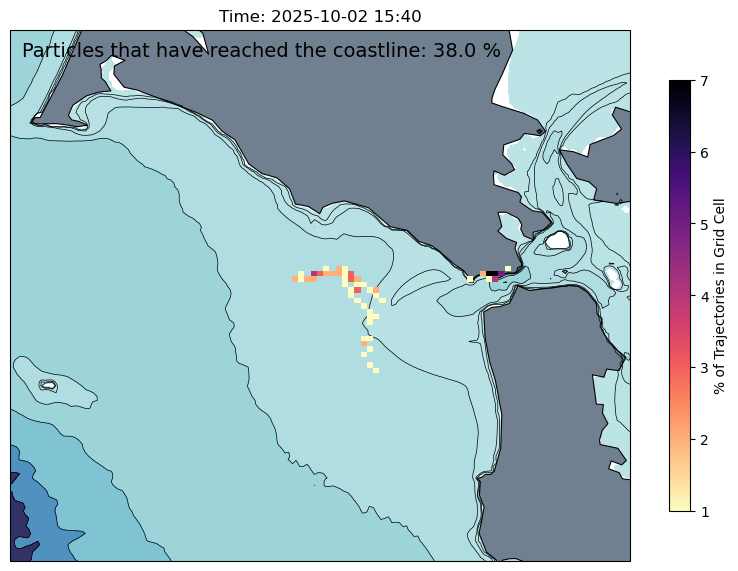

In [20]:
animate_heatmap(heat_da_masked, ds, first_strand_idx)

In [21]:
## Add in tide gauge data 
def get_tides_series(start_time,end_time):
    ''' Using the model output dataframe use the start and end times to get the tide series from NOAA Tides and Currents API
    Input:
        df: dataframe with a datetime column 't'
    Output:
        tides: dataframe with tide series from NOAA Tides and Currents API
    '''
    start_str = start_time.split('T')[0]
    end_str = end_time.split('T')[0]

    try:
        tides = pd.read_csv("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?begin_date={}&end_date={}&station=9414290&product=water_level&datum=MLLW&time_zone=gmt&units=metric&format=csv".format(start_str,end_str))
        tides['dateTime'] = pd.to_datetime(tides['Date Time'])
        tides.index = tides.dateTime
        return tides
    except Exception as e:
        print('Error in retrieving tide series from NOAA Tides and Currents API')
        print(e)
    return None

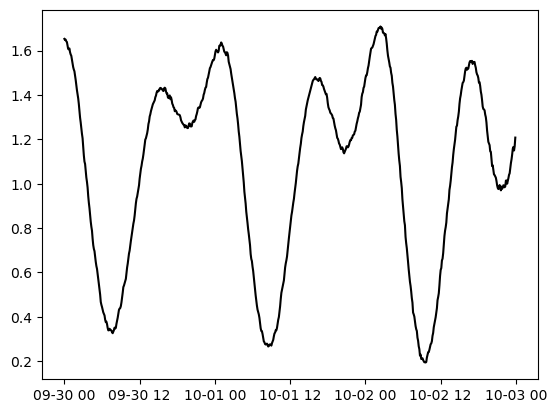

In [22]:
start_time = start_date
end_time = end_date
tide_series = get_tides_series(start_time,end_time)

plt.plot(tide_series['dateTime'],tide_series[' Water Level'],color='k')

In [41]:
tide_series.columns

Index(['Date Time', ' Water Level', ' Sigma', ' O or I (for verified)', ' F',
       ' R', ' L', ' Quality ', 'dateTime'],
      dtype='object')

In [30]:
end_time

'2025-10-02T15:40:00'

In [ ]:
def animate_heatmap_with_tides(heat_da_masked, ds, first_strand_idx):
    """
    Create an animation of the heatmap over time with a subplot of tides.
    """
    # --- Get tide series ---
    start_time = str(heat_da_masked.time.values[0])
    end_time = str(heat_da_masked.time.values[-1])
    tide_series = get_tides_series(start_time, end_time)

    # --- Create figure with two rows ---
    fig, (ax_map, ax_tide) = plt.subplots(
        2, 1, figsize=(10, 10),
        gridspec_kw={'height_ratios': [5, 1]},
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    fig.clf()
    gs = fig.add_gridspec(2, 1, height_ratios=[5, 1])
    ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
    ax_tide = fig.add_subplot(gs[1])

    # --- Bathymetry and coast ---
    ds_o = xr.open_dataset('/home/pdaniel/SurfaceCurrentMaps/DailyModelRuns/data/sf_bay_topo.nc')
    elv = ds_o['band_data'].values
    xx, yy = ds_o.x.values, ds_o.y.values
    levels = [0,5,10,20,50,100,200,500,1000]
    cmap = cmocean.cm.ice_r
    cmap_trunc = ListedColormap(cmap(np.linspace(0.1,1,256)))
    ax_map.contourf(xx, yy, -1*elv[0], zorder=-1, cmap=cmap_trunc, levels=levels)
    ax_map.contour(xx, yy, -1*elv[0], levels=levels[1:], colors='k', linewidths=0.5)

    coastline = cfeature.NaturalEarthFeature(
        'physical', 'coastline', '10m',
        edgecolor='black', facecolor='slategrey', linewidth=0.8
    )
    ax_map.add_feature(coastline, zorder=1)
    ax_map.set_xlim(-123.05, -122.35)
    ax_map.set_ylim(37.5, 38.1)

    # --- Heatmap mesh ---
    mesh = ax_map.pcolormesh(
        heat_da_masked.lon_bin,
        heat_da_masked.lat_bin,
        heat_da_masked.isel(time=0),
        cmap='magma_r',
        zorder=2
    )
    cbar = fig.colorbar(mesh, ax=ax_map, label='% of Trajectories in Grid Cell', shrink=0.7)
    n_particles = ds.sizes['trajectory']

    # --- Tide subplot ---
    ax_tide.plot(tide_series['dateTime'], tide_series[' Water Level'], color='k')
    ax_tide.set_ylabel("Water Level (m)")

    # Moving vertical line
    vline = ax_tide.axvline(tide_series['dateTime'].iloc[0], color='coral', lw=1)

    # --- Update function ---
    def update(frame):
        # Update map heatmap
        mesh.set_array(heat_da_masked.isel(time=frame).values.ravel())
        time_str = pd.to_datetime(heat_da_masked.time.values[frame]).strftime('%Y-%m-%d %H:%M')
        ax_map.set_title(f"Time: {time_str}", fontsize=16)

        # % stranded
        stranded_mask = (first_strand_idx >= 0) & (first_strand_idx <= frame)
        num_stranded_frame = (stranded_mask.sum() / n_particles * 100).round(2)
        for txt in ax_map.texts:
            txt.remove()
            
        ax_map.text(
            0.02, 0.95,
            f"Particles stranded: {num_stranded_frame} %",
            transform=ax_map.transAxes,
            fontsize=14,
            color='white',
            ha='left',
            va='top',
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3')
        )

        # Update tide vertical line
        vline.set_xdata([heat_da_masked.time.values[frame],
                         heat_da_masked.time.values[frame]])

        return mesh, vline

    # --- Animate ---
    ani = FuncAnimation(fig, update, frames=heat_da_masked.sizes['time'],
                        blit=True, interval=200)

    ani.save("../DailyModelRuns/model_output/heatmaps/trajectories_tides.gif",
             writer="pillow", fps=7)

#    plt.show()


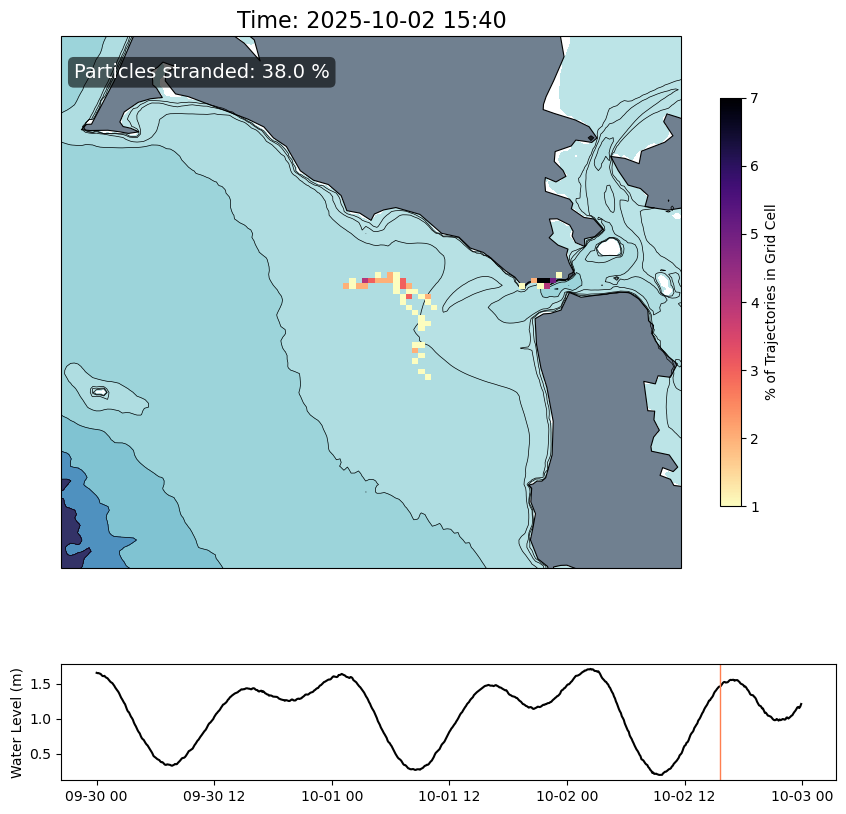

In [32]:
animate_heatmap_with_tides(heat_da_masked, ds, first_strand_idx)